In [8]:
import pandas as pd

# Step 1: Load your Excel file
file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Terrorism_repo\GDP\GDP1.xlsx"
gdp_sheet = 'Data'            # Sheet containing raw GDP data
countries_sheet = 'countries'  # Sheet containing country list (master)

# Step 2: Load GDP data
df_gdp = pd.read_excel(file_path, sheet_name=gdp_sheet)

# Step 3: Load country list (master order)
df_countries = pd.read_excel(file_path, sheet_name=countries_sheet)

# Rename column to match GDP sheet if needed
df_countries.columns = ['Country Name']

# Step 4: LEFT JOIN (keep all countries)
df_clean = df_countries.merge(
    df_gdp,
    on='Country Name',
    how='left'
)

# Step 5: Save cleaned data to a new sheet in the same Excel file
with pd.ExcelWriter(file_path, mode='a', if_sheet_exists='replace', engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='GDP_Cleaned', index=False)

print(
    "GDP data aligned to country list and saved in sheet 'GDP_Cleaned'. "
    "Shape:", df_clean.shape
)


GDP data aligned to country list and saved in sheet 'GDP_Cleaned'. Shape: (192, 69)


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import scipy.stats as stats
from scipy.stats import jarque_bera, shapiro

import statsmodels.api as sm


In [10]:
def wide_to_long(df,value_name):
    df = df.rename(columns={df.columns[0]: "country"})
    return df.melt(
        id_vars="country",
        var_name="year",
        value_name=value_name
    )

gdp = wide_to_long(pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Terrorism_repo\GDP\GDP1.xlsx", sheet_name="GDP_Cleaned"), value_name="GDP")

In [12]:
# Melt to long format
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Terrorism_repo\GDP\GDP1.xlsx", sheet_name="GDP_Cleaned")
gdp_long = df.melt(id_vars=["Country Name", "Country Code"],
                   var_name="Year",
                   value_name="GDP_Growth")

# Convert Year to int and GDP_Growth to float
gdp_long["Year"] = gdp_long["Year"].astype(int)
gdp_long["GDP_Growth"] = pd.to_numeric(gdp_long["GDP_Growth"], errors='coerce')

In [14]:
print(gdp_long)

      Country Name Country Code  Year  GDP_Growth
0      Afghanistan          AFG  1960         NaN
1          Albania          ALB  1960         NaN
2          Algeria          DZA  1960         NaN
3          Andorra          AND  1960         NaN
4           Angola          AGO  1960         NaN
...            ...          ...   ...         ...
12475      Vietnam          VNM  2024    7.091187
12476        Yemen          YEM  2024         NaN
12477       Zambia          ZMB  2024    3.820048
12478     Zimbabwe          ZWE  2024    1.742395
12479    Palestine          NaN  2024         NaN

[12480 rows x 4 columns]


In [ ]:


# Calculate % of NaN values in GDP_Growth for each country
nan_percent = gdp_long.groupby("Country Name")["GDP_Growth"].apply(lambda x: x.isna().mean() * 100)

# Sort descending to see countries with most missing values first
nan_percent = nan_percent.sort_values(ascending=False)

print(nan_percent)


Country Name
Cabo Verde       65
Congo            65
North Korea      65
Kyrgyzstan       65
Palestine        65
                 ..
United States     1
Uruguay           1
Venezuela         1
Zambia            1
Zimbabwe          1
Name: GDP_Growth, Length: 192, dtype: int64
Country Name
Cabo Verde       100.000000
Congo            100.000000
North Korea      100.000000
Kyrgyzstan       100.000000
Palestine        100.000000
                    ...    
United States      1.538462
Uruguay            1.538462
Venezuela          1.538462
Zambia             1.538462
Zimbabwe           1.538462
Name: GDP_Growth, Length: 192, dtype: float64


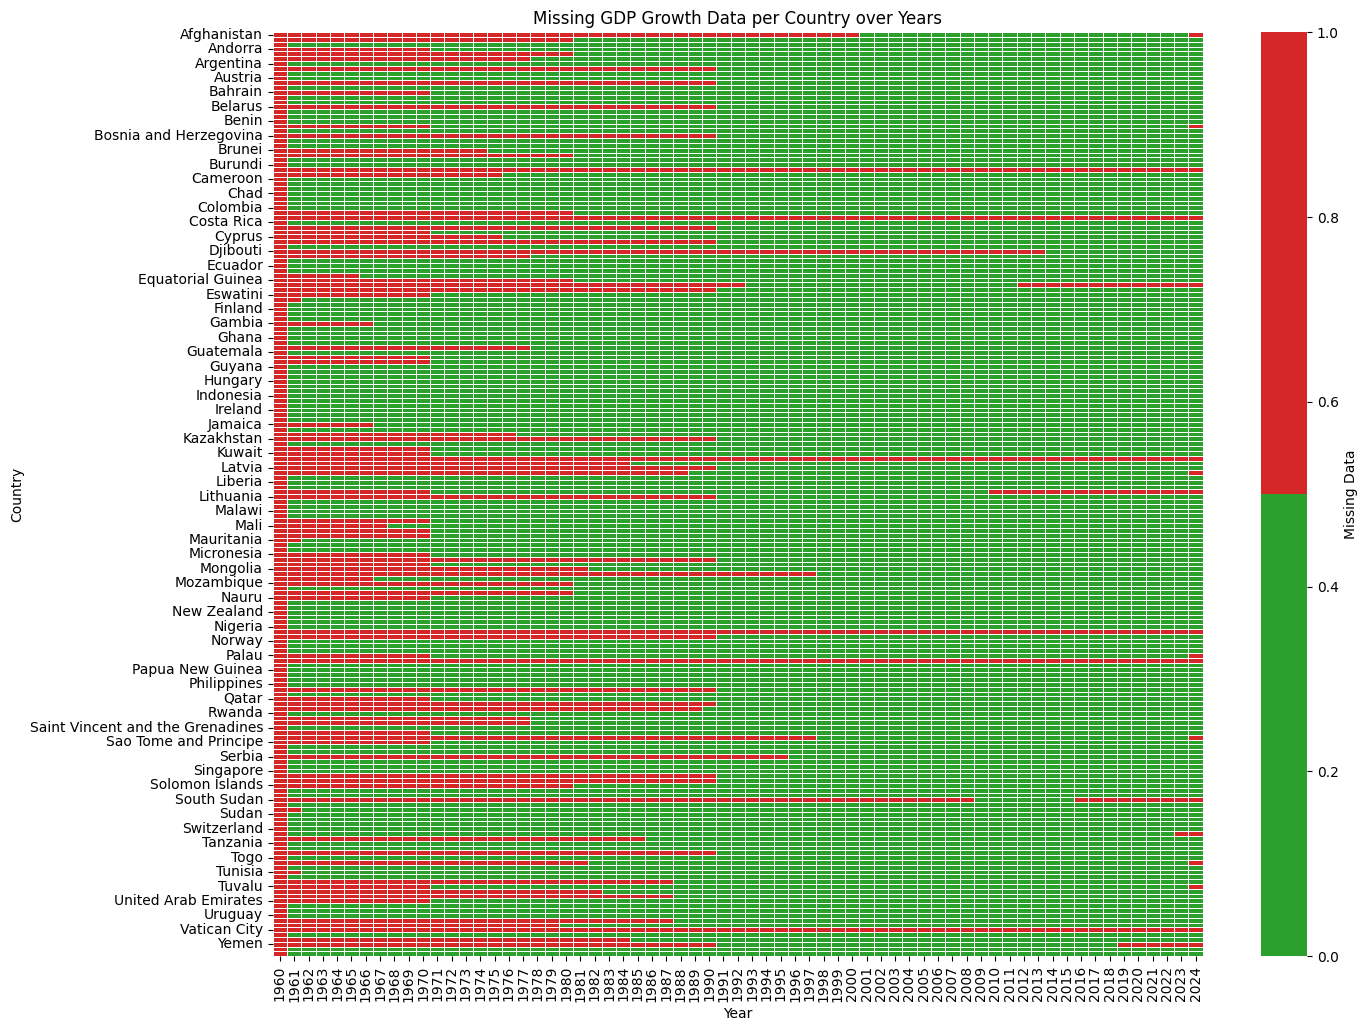

In [21]:
# Pivot data to have countries as rows and years as columns
gdp_pivot = gdp_long.pivot(index="Country Name", columns="Year", values="GDP_Growth")

# Create a boolean mask: True = missing, False = present
missing_mask = gdp_pivot.isna()

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(missing_mask, cmap=["#2ca02c", "#d62728"], cbar_kws={'label': 'Missing Data'}, linewidths=0.5)
plt.title("Missing GDP Growth Data per Country over Years")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

In [26]:
valid_countries = gdp_long.groupby("Country Name")["GDP_Growth"].apply(lambda x: x.notna().sum() > 0)
gdp_clean = gdp_long[gdp_long["Country Name"].isin(valid_countries[valid_countries].index)]
gdp_clean = gdp_clean.dropna(subset=["GDP_Growth"])
print(f"After removing countries with all NaN values, data shape: {gdp_clean.shape}")
print(gdp_clean)


After removing countries with all NaN values, data shape: (10177, 4)
      Country Name Country Code  Year  GDP_Growth
194        Algeria          DZA  1961  -13.605441
198      Argentina          ARG  1961    5.427843
200      Australia          AUS  1961    2.480857
201        Austria          AUT  1961    5.537979
203        Bahamas          BHS  1961   10.667097
...            ...          ...   ...         ...
12472      Vanuatu          VUT  2024    0.942185
12474    Venezuela          VEN  2024    5.300000
12475      Vietnam          VNM  2024    7.091187
12477       Zambia          ZMB  2024    3.820048
12478     Zimbabwe          ZWE  2024    1.742395

[10177 rows x 4 columns]


In [27]:
import numpy as np

# Check number of NaNs, inf, -inf
print("NaNs:", gdp_clean["GDP_Growth"].isna().sum())
print("Infinite values:", np.isinf(gdp_clean["GDP_Growth"]).sum())
print("Negative Infinite values:", np.isneginf(gdp_clean["GDP_Growth"]).sum())

NaNs: 0
Infinite values: 0
Negative Infinite values: 0


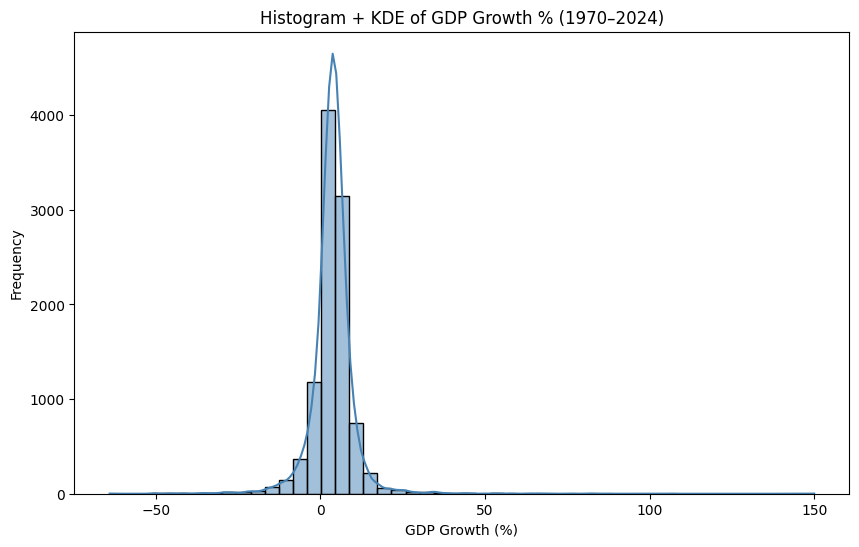

<Figure size 600x600 with 0 Axes>

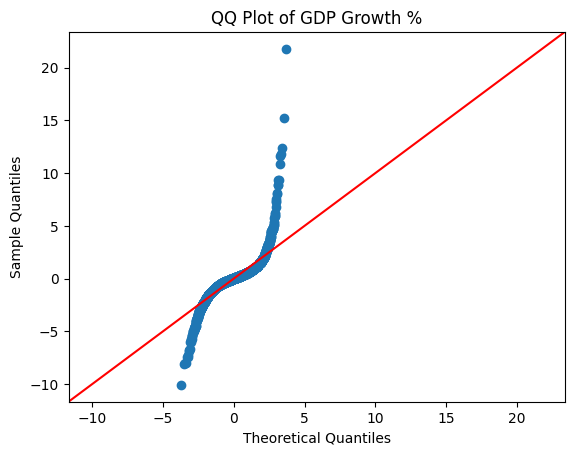

In [28]:

# Histogram + KDE
plt.figure(figsize=(10,6))
sns.histplot(gdp_clean["GDP_Growth"], bins=50, kde=True, color='steelblue')
plt.title("Histogram + KDE of GDP Growth % (1970–2024)")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")
plt.show()

# QQ Plot
plt.figure(figsize=(6,6))
sm.qqplot(gdp_clean["GDP_Growth"], line='45', fit=True)
plt.title("QQ Plot of GDP Growth %")
plt.show()


In [31]:
skewness = stats.skew(gdp_clean["GDP_Growth"])
kurtosis = stats.kurtosis(gdp_clean["GDP_Growth"])  # excess kurtosis
print(f"Skewness: {skewness:.4f}")
print(f"Excess Kurtosis: {kurtosis:.4f}")

Skewness: 1.9340
Excess Kurtosis: 46.4541


In [30]:
from scipy.stats import shapiro, kstest, anderson, norm
import numpy as np

# If dataset > 5000, take sample for Shapiro-Wilk
sample = gdp_clean["GDP_Growth"].sample(5000, random_state=42) if len(gdp_clean) > 5000 else gdp_clean["GDP_Growth"]



# Kolmogorov-Smirnov Test
mu, sigma = gdp_clean["GDP_Growth"].mean(), gdp_clean["GDP_Growth"].std()
stat, p = kstest(gdp_clean["GDP_Growth"], 'norm', args=(mu, sigma))
print("\nKolmogorov-Smirnov Test")
print(f"Statistic={stat:.4f}, p-value={p:.4f}")

# Anderson-Darling Test
result = anderson(gdp_clean["GDP_Growth"], dist='norm')
print("\nAnderson-Darling Test")
print(f"Statistic={result.statistic:.4f}")
for level, crit in zip(result.significance_level, result.critical_values):
    print(f"  {level}%: {crit:.4f}")



Kolmogorov-Smirnov Test
Statistic=0.1223, p-value=0.0000

Anderson-Darling Test
Statistic=394.8679
  15.0%: 0.5760
  10.0%: 0.6560
  5.0%: 0.7870
  2.5%: 0.9180
  1.0%: 1.0920


Formal normality tests reject the null hypothesis of normality. Given the large sample size (n ≈ 12,000) and the heavy-tailed nature of GDP growth, this result is expected. Therefore, methods assuming strict normality are avoided.

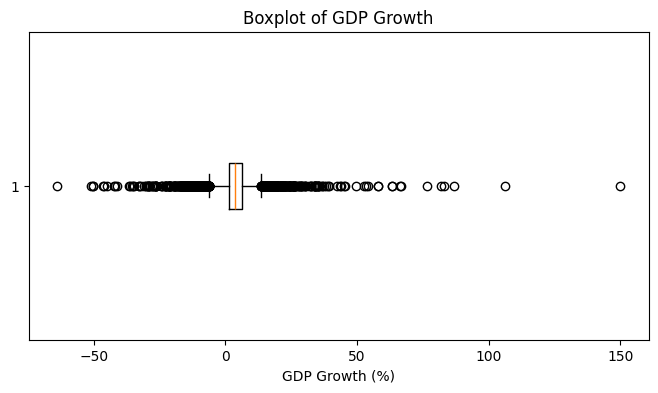

In [33]:
#BOXPLOT
plt.figure(figsize=(8,4))
plt.boxplot(gdp_clean["GDP_Growth"], vert=False)
plt.title("Boxplot of GDP Growth")
plt.xlabel("GDP Growth (%)")
plt.show()


The boxplot of GDP growth reveals a highly skewed and heavy-tailed distribution with numerous extreme observations. These values correspond to genuine macroeconomic shocks rather than measurement errors and are therefore retained in the analysis. Robust standard errors and alternative specifications are used to ensure that results are not driven by extreme observations.

IQR Outliers Count: 771
IQR Outliers %: 7.5759064557335165


<Axes: xlabel='GDP_Growth', ylabel='Count'>

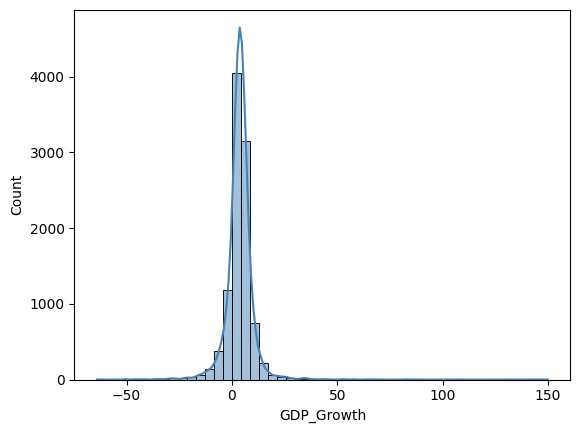

In [34]:
Q1 = np.percentile(gdp_clean["GDP_Growth"], 25)
Q3 = np.percentile(gdp_clean["GDP_Growth"], 75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

iqr_outliers = (gdp_clean["GDP_Growth"] < lower_iqr) | (gdp_clean["GDP_Growth"] > upper_iqr)

print("IQR Outliers Count:", iqr_outliers.sum())
print("IQR Outliers %:", iqr_outliers.mean() * 100)
sns.histplot(gdp_clean["GDP_Growth"], bins=50, kde=True, color='steelblue')

Using the IQR criterion, approximately 7.6% of GDP growth observations are classified as outliers. Given the skewed and heavy-tailed nature of macroeconomic growth data, these observations represent genuine economic shocks rather than measurement errors and are therefore retained. Robust estimation techniques are employed to ensure that results are not driven by extreme values.

In [35]:
#EXTREME QUANTILE ANALYSIS
p1, p99 = np.percentile(gdp_clean["GDP_Growth"], [1, 99])

extreme_quantiles = (gdp_clean["GDP_Growth"] < p1) | (gdp_clean["GDP_Growth"] > p99)

print("1–99% Extreme Values Count:", extreme_quantiles.sum())
print("Lower 1% cutoff:", p1)
print("Upper 99% cutoff:", p99)


1–99% Extreme Values Count: 204
Lower 1% cutoff: -15.105581184723707
Upper 99% cutoff: 22.076249537949412


Percentile-based diagnostics indicate that approximately 1.7% of GDP growth observations fall outside the 1st and 99th percentiles (−15.1% and +22.1%, respectively). These values correspond to rare but genuine macroeconomic shocks. All observations are retained in the main analysis, while winsorized specifications are estimated as robustness checks.